<a href="https://colab.research.google.com/github/ItsArghyaPal/FIT5215/blob/main/FIT3181_5215_Kaggle_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inclass Kaggle competition week 4

## Running on Google Colab

This notebook is designed to run in Google Colab. Run the download cell once
per Colab session, then unzip the archive into the current runtime.

The archive contains separate NumPy tensors for training, validation, and test,
plus the loader, metadata, and Kaggle sample submission.

In [ ]:
!gdown https://drive.google.com/file/d/1le0jcQLNaJd0fKc1s6Sdyhig8vYFUSQA/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

# Backup URLs:
# !gdown https://drive.google.com/file/d/1TuZW2Zn9BUQS4Bmd5KbuQVbTljEeV6AR/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

# !gdown https://drive.google.com/file/d/1OWxpW3CyqHELrLpNfaJpu9JRz-xYcI4z/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

# !gdown https://drive.google.com/file/d/1OgbuRYctlKc0p8bvhg-8vmQeq5f57J0b/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

# !gdown https://drive.google.com/file/d/1frQFS_nGXdRMEhCgZH9cYeA3noTA5PHo/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

# !gdown https://drive.google.com/file/d/1v5ZBIVBx1SJY1uW6CflecCjaQSzopRRo/view?usp=sharing --fuzzy -O data_kaggle_week4.zip

Downloading...
From: https://drive.google.com/uc?id=1le0jcQLNaJd0fKc1s6Sdyhig8vYFUSQA
To: /content/data_kaggle_week4.zip
100% 5.33M/5.33M [00:00<00:00, 128MB/s]


In [ ]:
from pathlib import Path

!unzip -o -q data_kaggle_week4.zip
!ls data_kaggle_week4

DATA_ROOT = Path('./data_kaggle_week4')
required_files = [
    'train_images.npy',
    'train_labels.npy',
    'validation_images.npy',
    'validation_labels.npy',
    'test_images.npy',
    'sample_submission.csv',
    'dataweek4.py',
]
missing_files = [name for name in required_files if not (DATA_ROOT / name).is_file()]
if missing_files:
    raise FileNotFoundError(f'Missing data files: {missing_files}')
print('Data root:', DATA_ROOT.resolve())

dataweek4.py	       test_images.npy	 validation_images.npy
sample_submission.csv  train_images.npy  validation_labels.npy
tensor_metadata.json   train_labels.npy
Data root: /content/data_kaggle_week4


## Imports and reproducibility

In [ ]:
import copy
import importlib.util
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

SEED = 1029

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('Device:', device)

PyTorch: 2.11.0+cpu
Device: cpu


## Data Preprocess

In [ ]:
# Import WEEK4 directly from the downloaded data folder.
loader_path = DATA_ROOT / 'dataweek4.py'
spec = importlib.util.spec_from_file_location('week4_loader_module', loader_path)
week4_loader = importlib.util.module_from_spec(spec)
spec.loader.exec_module(week4_loader)
WEEK4 = week4_loader.WEEK4

# ToTensor converts each 64x64 RGB image to a float tensor shaped (3, 64, 64).
train_transform = transforms.Compose([
    transforms.ToTensor(),
])
evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = WEEK4(DATA_ROOT, split='train', transform=train_transform)
validation_dataset = WEEK4(
    DATA_ROOT, split='validation', transform=evaluation_transform
)
test_dataset = WEEK4(DATA_ROOT, split='test', transform=evaluation_transform)

num_classes = len(train_dataset.classes)

print('Classes:', train_dataset.classes)
print('Train:', len(train_dataset))
print('Validation:', len(validation_dataset))
print('Test:', len(test_dataset))

Classes: ['class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7']
Train: 496
Validation: 112
Test: 320


### Data Loader and Examples

Training batch: torch.Size([256, 3, 64, 64]) torch.Size([256])
Test batch: torch.Size([256, 3, 64, 64])


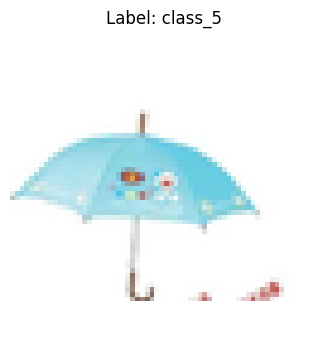

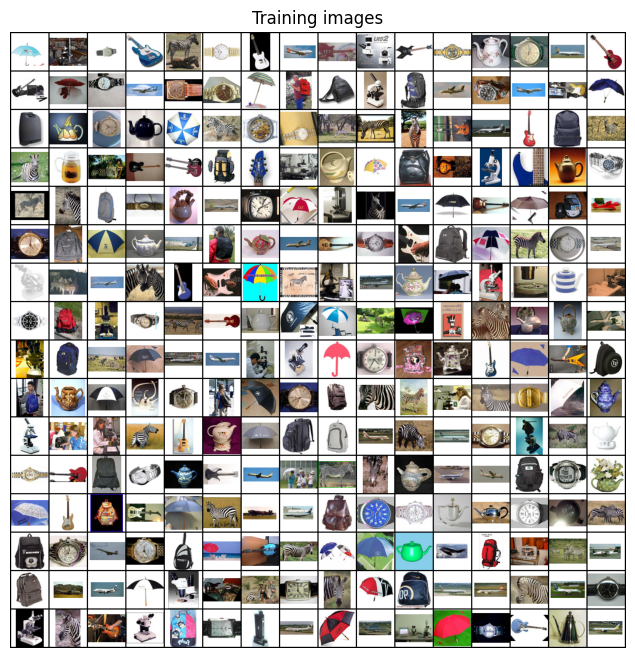

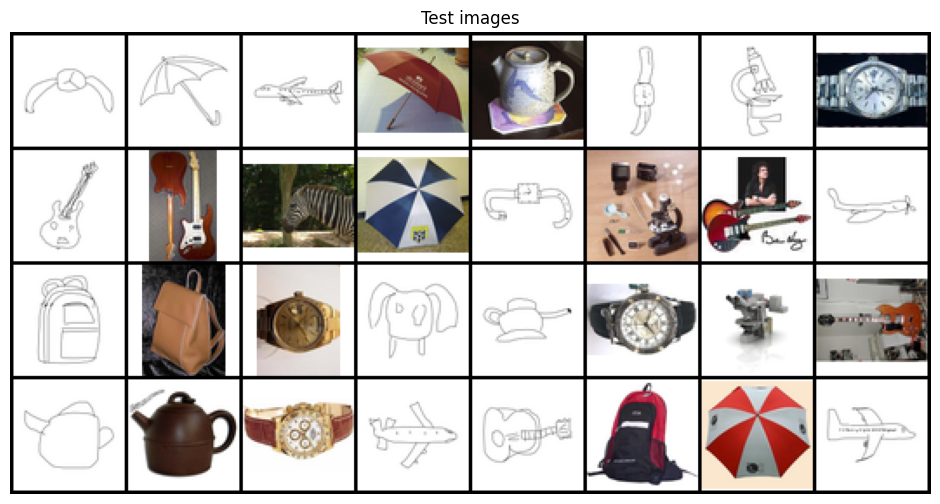

In [ ]:
BATCH_SIZE = 128
NUM_WORKERS = 0
pin_memory = device.type == 'cuda'
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
train_evaluation_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

images, labels = next(iter(train_evaluation_loader))
test_images, _ = next(iter(test_loader))
print('Training batch:', images.shape, labels.shape)
print('Test batch:', test_images.shape)

plt.figure(figsize=(4, 4))
plt.imshow(images[0].permute(1, 2, 0))
plt.title(f'Label: {train_dataset.classes[int(labels[0])]}')
plt.axis('off')
plt.show()

plt.figure(figsize=(16, 8))
plt.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
plt.title('Training images')
plt.axis('off')
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(make_grid(test_images[:32], nrow=8).permute(1, 2, 0))
plt.title('Test images')
plt.axis('off')
plt.show()

# Reset the training seed after sampling images for display.
seed_everything(SEED)

## Define Models

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.ensure_feature_size = nn.AdaptiveAvgPool2d((16, 16))
        self.fc = nn.Linear(64 * 16 * 16, num_classes)

    def forward(self, inputs):
        # Native input: (batch, 3, 64, 64). Pooling changes 64 -> 32 -> 16.
        outputs = self.pool(F.relu(self.conv1(inputs)))
        outputs = self.pool(F.relu(self.conv2(outputs)))
        outputs = self.ensure_feature_size(outputs)
        outputs = torch.flatten(outputs, 1)
        return self.fc(outputs)

model = CNN(num_classes=num_classes).to(device)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (ensure_feature_size): AdaptiveAvgPool2d(output_size=(16, 16))
  (fc): Linear(in_features=16384, out_features=8, bias=True)
)
Trainable parameters: 150472


## Training the Model

In [ ]:
@torch.inference_mode()
def evaluate(model, loader, loss_function):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for images, labels in loader:
        images = images.to(device=device, dtype=torch.float32)
        labels = labels.to(device=device, dtype=torch.long)
        logits = model(images)
        batch_size = labels.size(0)
        total_loss += float(loss_function(logits, labels)) * batch_size
        total_correct += int((logits.argmax(dim=1) == labels).sum())
        total_examples += batch_size
    return total_loss / total_examples, total_correct / total_examples


def train_model(model, epochs, learning_rate, weight_decay=0.0):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'validation_loss': [],
        'validation_accuracy': [],
        'learning_rate': [],
    }
    best_validation_accuracy = -1.0
    best_validation_loss = float('inf')
    best_epoch = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images = images.to(device=device, dtype=torch.float32)
            labels = labels.to(device=device, dtype=torch.long)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(images), labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

        train_loss, train_accuracy = evaluate(
            model, train_evaluation_loader, loss_function
        )
        validation_loss, validation_accuracy = evaluate(
            model, validation_loader, loss_function
        )
        current_lr = float(optimizer.param_groups[0]['lr'])
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['validation_loss'].append(validation_loss)
        history['validation_accuracy'].append(validation_accuracy)
        history['learning_rate'].append(current_lr)

        if (validation_accuracy, -validation_loss, -(epoch + 1)) > (
            best_validation_accuracy,
            -best_validation_loss,
            -best_epoch,
        ):
            best_validation_accuracy = validation_accuracy
            best_validation_loss = validation_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch + 1:02d}/{epochs:02d} | '
            f'train loss {train_loss:.4f}, accuracy {train_accuracy:.2%} | '
            f'validation loss {validation_loss:.4f}, '
            f'accuracy {validation_accuracy:.2%} | lr {current_lr:.6g}'
        )

    return history, best_state, best_validation_accuracy

### Model Selection

In [ ]:
EPOCHS = 30
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0

history, best_state, best_validation_accuracy = train_model(
    model,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

model.load_state_dict(best_state)
model.to(device)

loss_function = nn.CrossEntropyLoss()
best_train_loss, best_train_accuracy = evaluate(
    model, train_evaluation_loader, loss_function
)
best_validation_loss, best_validation_accuracy = evaluate(
    model, validation_loader, loss_function
)

print(f'Best train accuracy: {best_train_accuracy:.2%}')
print(f'Best validation accuracy: {best_validation_accuracy:.2%}')

Epoch 01/30 | train loss 2.0541, accuracy 15.32% | validation loss 2.0784, accuracy 13.39% | lr 0.00049863
Epoch 02/30 | train loss 1.9365, accuracy 34.48% | validation loss 1.9787, accuracy 24.11% | lr 0.000494537
Epoch 03/30 | train loss 1.8188, accuracy 46.57% | validation loss 1.8885, accuracy 41.96% | lr 0.000487764
Epoch 04/30 | train loss 1.6474, accuracy 46.77% | validation loss 1.7597, accuracy 38.39% | lr 0.000478386
Epoch 05/30 | train loss 1.4790, accuracy 56.05% | validation loss 1.6458, accuracy 47.32% | lr 0.000466506
Epoch 06/30 | train loss 1.3591, accuracy 54.23% | validation loss 1.5824, accuracy 41.07% | lr 0.000452254
Epoch 07/30 | train loss 1.2645, accuracy 57.86% | validation loss 1.5392, accuracy 47.32% | lr 0.000435786
Epoch 08/30 | train loss 1.2010, accuracy 57.26% | validation loss 1.5012, accuracy 43.75% | lr 0.000417283
Epoch 09/30 | train loss 1.1228, accuracy 63.91% | validation loss 1.4598, accuracy 50.89% | lr 0.000396946
Epoch 10/30 | train loss 1.07

## Visualizing the Performance and Loss

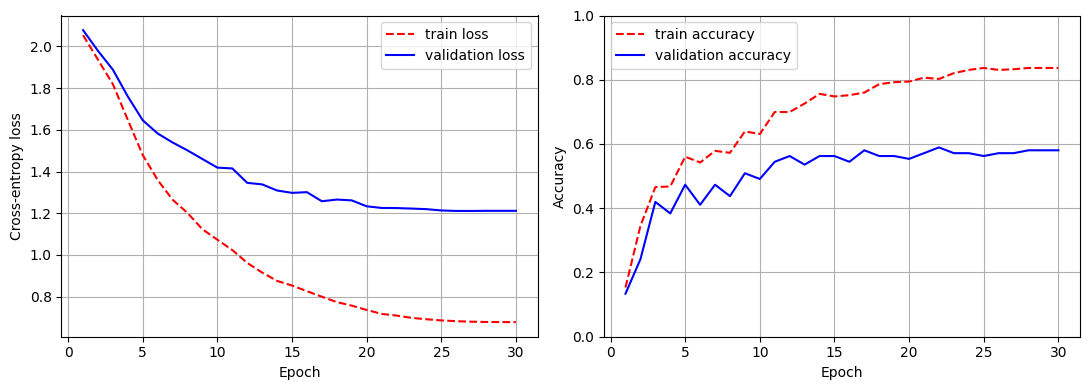

In [ ]:
epochs = np.arange(1, len(history['train_accuracy']) + 1)
figure, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(11, 4))

loss_axis.plot(epochs, history['train_loss'], 'r--', label='train loss')
loss_axis.plot(epochs, history['validation_loss'], 'b-', label='validation loss')
loss_axis.set_xlabel('Epoch')
loss_axis.set_ylabel('Cross-entropy loss')
loss_axis.grid(True)
loss_axis.legend()

accuracy_axis.plot(
    epochs, history['train_accuracy'], 'r--', label='train accuracy'
)
accuracy_axis.plot(
    epochs, history['validation_accuracy'], 'b-', label='validation accuracy'
)
accuracy_axis.set_xlabel('Epoch')
accuracy_axis.set_ylabel('Accuracy')
accuracy_axis.set_ylim(0, 1)
accuracy_axis.grid(True)
accuracy_axis.legend()

figure.tight_layout()
plt.show()

## Evaluate on the test set and create submission.csv

In [ ]:
@torch.inference_mode()
def predict(model, loader):
    model.eval()
    predictions = []
    for images, _ in loader:
        logits = model(images.to(device=device, dtype=torch.float32))
        predictions.extend(logits.argmax(dim=1).cpu().tolist())
    return predictions

predictions = predict(model, test_loader)
submission_template = pd.read_csv(DATA_ROOT / 'sample_submission.csv')
if list(submission_template.columns) != ['ImageId', 'Label']:
    raise ValueError('The sample submission columns must be ImageId and Label')
if len(predictions) != len(submission_template):
    raise ValueError('The prediction count does not match the test set')

submission = submission_template.copy()
submission['Label'] = predictions
if submission['ImageId'].duplicated().any():
    raise ValueError('Submission ImageId values must be unique')
if not submission['Label'].between(0, num_classes - 1).all():
    raise ValueError('Submission labels are outside the valid range')
submission_path = Path('submission.csv')
submission.to_csv(submission_path, index=False)

print('Submission:', submission_path)
print('Rows:', len(submission))
display(submission.head())

Submission: submission.csv
Rows: 320


,ImageId,Label
0,1,5
1,2,5
2,3,5
3,4,5
4,5,0


# Upload result to Kaggle competition

Download `submission.csv` from the Colab file browser and upload it on Kaggle.